# Intensity Transformations and Neighbourhood Filtering

### EN3160 Image Processing and Computer Vision - Assignment 01
R. M. S. H. Ratnayake
(230548R)

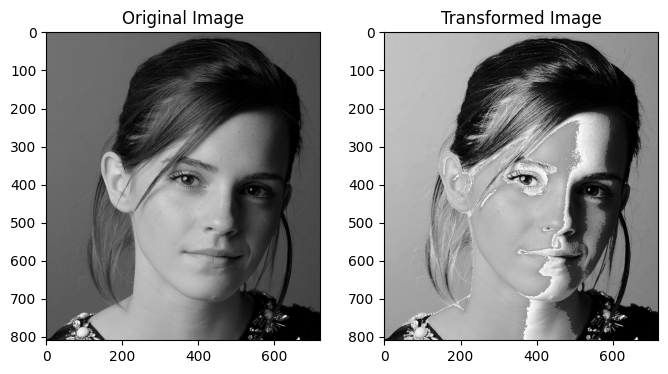

In [13]:
#Question 1

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread("emma.jpg", cv.IMREAD_GRAYSCALE)
def intensity_transform(im, breakpoints):
    
    c = np.array(breakpoints)
    t1 = np.linspace(0, c[0, 1], c[0, 0] + 1).astype('uint8')  
    t2 = np.linspace(c[1, 1], c[2, 1], c[2, 0] - c[1, 0]).astype('uint8')
    t3 = np.linspace(c[3, 1], 255, 255 - c[3, 0]).astype('uint8')

    # Concatenate segments into a valid 256x1 Look-Up Table
    transform = np.concatenate((t1, t2, t3), axis=0).astype('uint8').reshape(256, 1)
    image_transformed = cv.LUT(im, transform)
    
    return image_transformed, transform


breakpoints = [(50, 50), (50, 100), (150, 255), (150, 150)]

# Apply transformation
img, tr = intensity_transform(f, breakpoints)

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[1].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image")
plt.show()


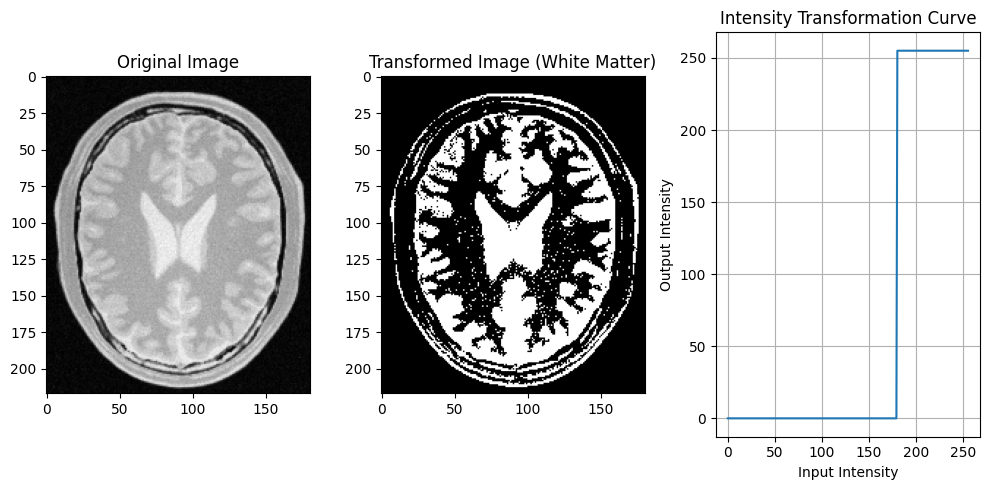

In [87]:
# Question 2

f = cv.imread("brain_proton_density_slice.png", cv.IMREAD_GRAYSCALE)

#part a).
t1= np.linspace(0, 0, 180, endpoint=False).astype("uint8")
t2= np.linspace(255, 255, 76).astype("uint8")
tr1= np.concatenate((t1, t2)).reshape(256, 1)

img_wm = cv.LUT(f, tr1)
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")

ax[1].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (White Matter)")

ax[2].plot(tr1)
ax[2].set_title("Intensity Transformation Curve")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()


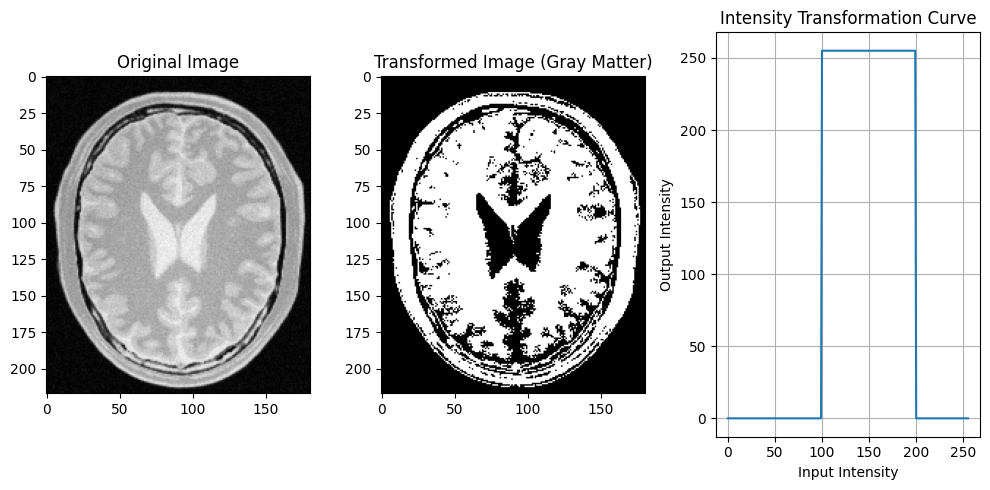

In [86]:
# Question 2
#part b).
gm_low   = np.linspace(0, 0, 100, endpoint=False).astype("uint8")
gm_boost = np.linspace(255, 255, 100, endpoint=False).astype("uint8")
gm_high  = np.linspace(0, 0, 56).astype("uint8")
tr_gm    = np.concatenate((gm_low, gm_boost, gm_high)).reshape(256, 1)

img_gm = cv.LUT(f, tr_gm)
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")

ax[1].imshow(img_gm, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (Gray Matter)")

ax[2].plot(tr_gm)
ax[2].set_title("Intensity Transformation Curve")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

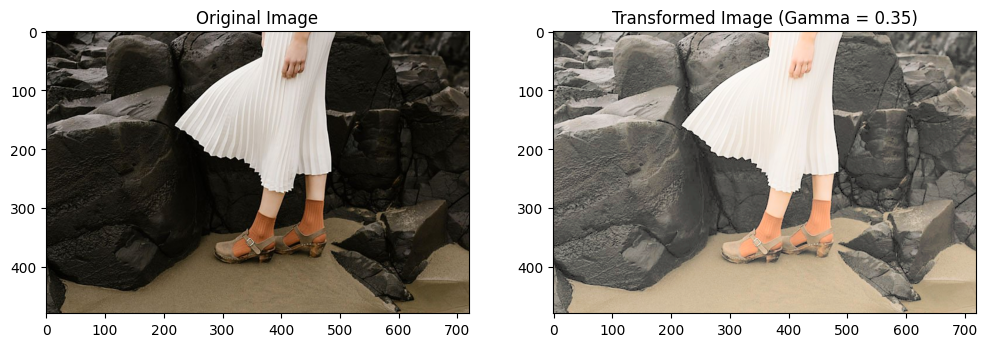

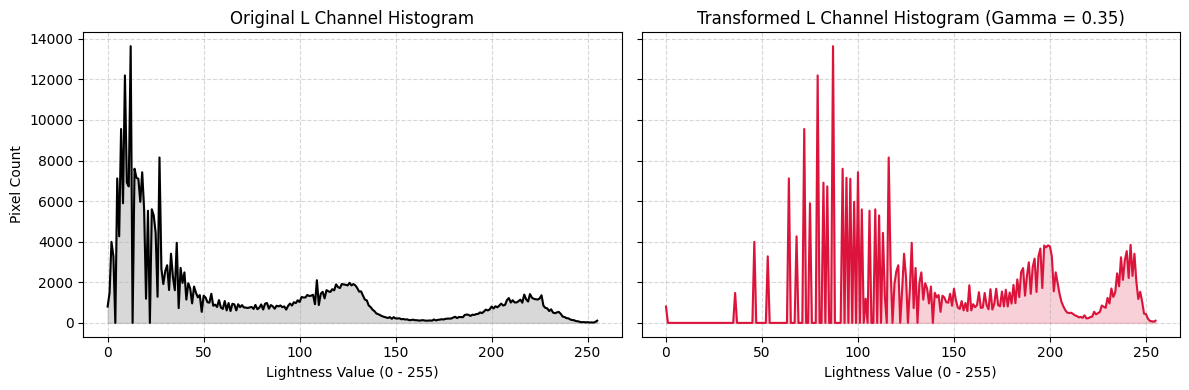

In [59]:
# Question 3
fig = cv.imread("highlights_and_shadows.jpg")
rgb_original = cv.cvtColor(fig, cv.COLOR_BGR2RGB)

img_lab = cv.cvtColor(fig, cv.COLOR_BGR2LAB)
L, a, b = cv.split(img_lab) #splitting to L*a*b planes

gamma= 0.35
tr = np.array([(((i/255)**gamma)*255) for i in range(256)], dtype=np.uint8)
L_new = cv.LUT(L, tr) #Transformation

modified= cv.merge([L_new, a, b])
bgr_result = cv.cvtColor(modified, cv.COLOR_LAB2BGR)
rgb_result = cv.cvtColor(bgr_result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(rgb_original)
ax[0].set_title("Original Image")
ax[1].imshow(rgb_result)
ax[1].set_title(f"Transformed Image (Gamma = {gamma})")

# Plotting the histogram
hist_before = cv.calcHist([L], [0], None, [256], [0, 256])
hist_after = cv.calcHist([L_new], [0], None, [256], [0, 256])
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Original L Channel Histogram
ax[0].plot(hist_before, color="black", linewidth=1.5)
ax[0].fill_between(range(256), hist_before.ravel(), color="gray", alpha=0.3)
ax[0].set_title("Original L Channel Histogram")
ax[0].set_xlabel("Lightness Value (0 - 255)")
ax[0].set_ylabel("Pixel Count")
ax[0].grid(True, linestyle="--", alpha=0.5)

# Transformed L Channel Histogram
ax[1].plot(hist_after, color="crimson", linewidth=1.5)
ax[1].fill_between(range(256), hist_after.ravel(), color="crimson", alpha=0.2)
ax[1].set_title(f"Transformed L Channel Histogram (Gamma = {gamma})")
ax[1].set_xlabel("Lightness Value (0 - 255)")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

$\gamma$= 0.35

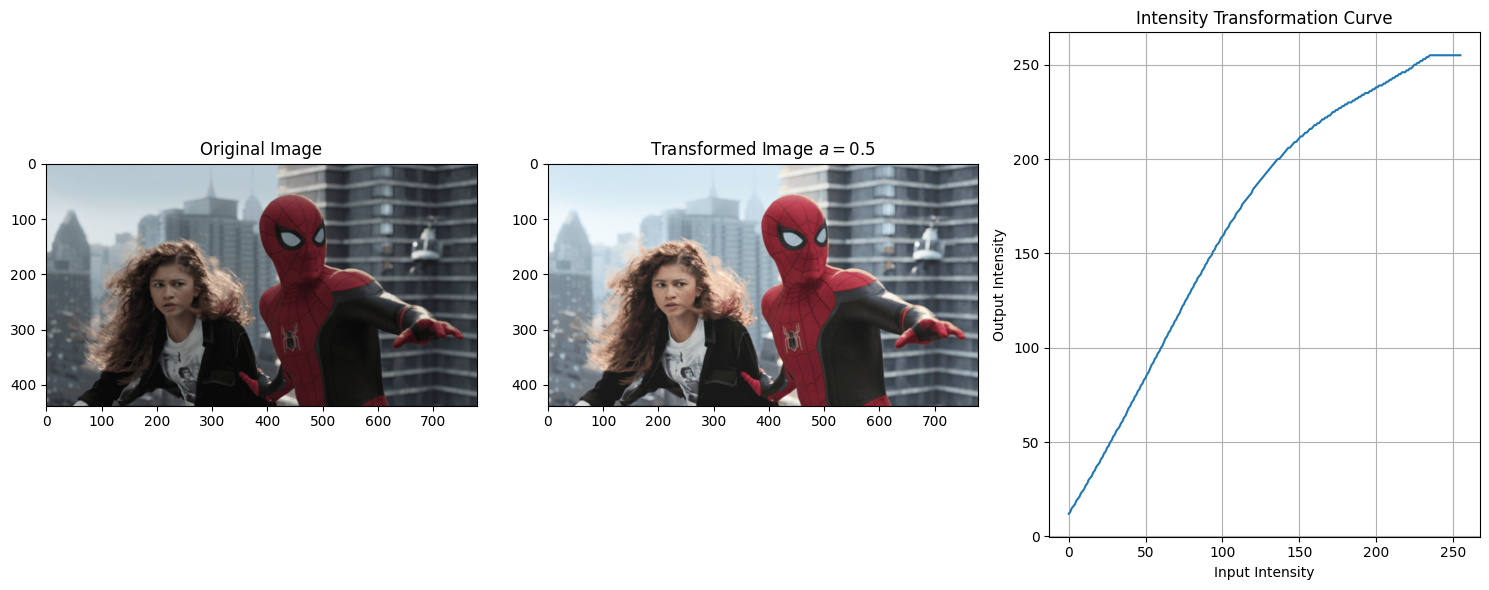

In [90]:
#Question 4
fig=  cv.imread("spider.png")
rgb_original= cv.cvtColor(fig, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(fig, cv.COLOR_BGR2HSV) # convert to hue, sturation, and value
h,s,v= cv.split(img_hsv)

a=0.5; sigma=70;
def f(x):
    return min(x+a*128*np.exp(-(x-128)**2/(2*sigma**2)),255)
tr = np.array([np.round(f(i)) for i in range(256)], dtype=np.uint8)
v_new=cv.LUT(v,tr)
modified= cv.merge([h,s,v_new])
bgr_result = cv.cvtColor(modified, cv.COLOR_HSV2BGR)
rgb_result = cv.cvtColor(bgr_result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 6))
ax[0].imshow(rgb_original)
ax[0].set_title("Original Image")
ax[1].imshow(rgb_result)
ax[1].set_title(f"Transformed Image $a=${a}")
ax[2].plot(tr)
ax[2].set_title("Intensity Transformation Curve")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)
plt.tight_layout()
plt.show()